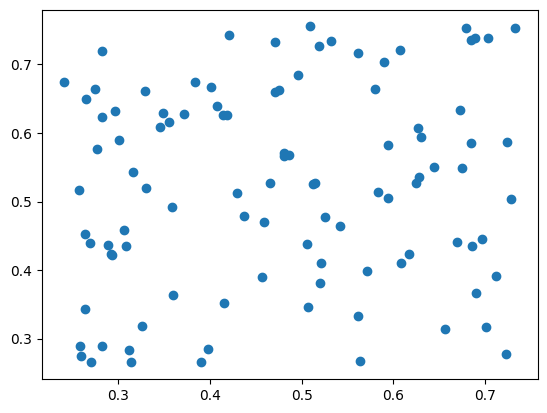

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 100

x = np.random.rand(N)
y = np.random.rand(N)

vx = np.zeros(N)
vy = np.zeros(N)

for step in range(10):

    for i in range(N):
        for j in range(N):

            if i != j:

                dx = x[j] - x[i]
                dy = y[j] - y[i]

                vx[i] += dx * 0.0001
                vy[i] += dy * 0.0001

    x += vx
    y += vy

plt.scatter(x, y)
plt.show()

In [ ]:
from numba import cuda

print(cuda.is_available())

#Aparecer "TRUE" = a GPU esta pronta

True


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


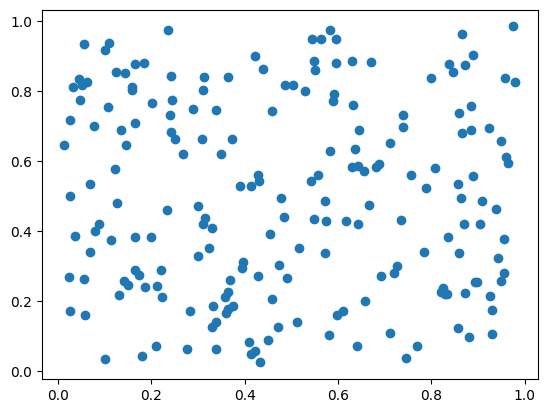

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# importa CUDA do Numba
from numba import cuda

# QUANTIDADE DE CORPOS
N = 200

# POSIÇÕES ALEATÓRIAS DOS CORPOS
# cada corpo terá:
# x -> posição horizontal
# y -> posição vertical

x = np.random.rand(N)
y = np.random.rand(N)

# VELOCIDADES INICIAIS

vx = np.zeros(N)
vy = np.zeros(N)

# ENVIAR DADOS PARA GPU
# agora os dados saem da RAM
# e vão para memória da GPU

d_x = cuda.to_device(x)
d_y = cuda.to_device(y)

d_vx = cuda.to_device(vx)
d_vy = cuda.to_device(vy)

# KERNEL CUDA
# função que será executada na GPU

@cuda.jit
def mover_corpos(x, y, vx, vy):

    # DESCOBRIR QUAL THREAD EU SOU
    # cada thread cuidará de 1 corpo

    i = cuda.grid(1)

    # evita threads inválidas
    if i < x.size:

        # COMPARAR COM TODOS OS CORPOS

        for j in range(x.size):

            # evita comparar o corpo com ele mesmo
            if i != j:


                # DIFERENÇA DE POSIÇÃO
                dx = x[j] - x[i]
                dy = y[j] - y[i]

                # ALTERAR VELOCIDADE
                # o corpo é puxado pelos outros
                vx[i] += dx * 0.0001
                vy[i] += dy * 0.0001


        # ATUALIZAR POSIÇÃO
        x[i] += vx[i]
        y[i] += vy[i]


# CONFIGURAÇÃO CUDA

# quantidade de threads por bloco
threads = 256

# quantidade de blocos necessarios
blocks = (N + threads - 1) // threads


# EXECUTAR KERNEL NA GPU
mover_corpos[blocks, threads](d_x, d_y, d_vx, d_vy)


# COPIAR RESULTADOS DA GPU PARA CPU
x = d_x.copy_to_host()
y = d_y.copy_to_host()


# MOSTRAR RESULTADO
plt.scatter(x, y)
plt.show()

In [ ]:
import numpy as np
import time


#MEDIR TEMPO CPU
#ANOTE O TEMPO COM N=100; N=200 e N=500
N = 100

x = np.random.rand(N)
y = np.random.rand(N)

vx = np.zeros(N)
vy = np.zeros(N)

inicio = time.time()

for step in range(20):

    for i in range(N):
        for j in range(N):

            if i != j:

                dx = x[j] - x[i]
                dy = y[j] - y[i]

                vx[i] += dx * 0.0001
                vy[i] += dy * 0.0001

    x += vx
    y += vy

fim = time.time()

print("Tempo CPU:", fim - inicio)

Tempo CPU: 7.690136909484863


In [ ]:
import numpy as np
import time
from numba import cuda

#MEDIR TEMPO GPU
#ANOTE O TEMPO COM N=100; N=200 e N=500
N = 500

x = np.random.rand(N)
y = np.random.rand(N)

vx = np.zeros(N)
vy = np.zeros(N)

d_x = cuda.to_device(x)
d_y = cuda.to_device(y)

d_vx = cuda.to_device(vx)
d_vy = cuda.to_device(vy)

@cuda.jit
def mover_corpos(x, y, vx, vy):

    i = cuda.grid(1)

    if i < x.size:

        for j in range(x.size):

            if i != j:

                dx = x[j] - x[i]
                dy = y[j] - y[i]

                vx[i] += dx * 0.0001
                vy[i] += dy * 0.0001

        x[i] += vx[i]
        y[i] += vy[i]

threads = 256
blocks = (N + threads - 1) // threads

inicio = time.time()

mover_corpos[blocks, threads](d_x, d_y, d_vx, d_vy)

# faz a CPU esperar a  GPU terminar
cuda.synchronize()

fim = time.time()

print("Tempo GPU:", fim - inicio)

Tempo GPU: 0.1560959815979004


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


| N | Tempo CPU (s) | Tempo GPU (s) |
|---|---------------|---------------|
|100|   0.27937     |   0.167180    |
|200|   1.52044     |   0.153264    |
|500|   7.690137    |   0.222632    |

In [ ]:
import numpy as np
import time
from numba import cuda, float32
import math

# -----------------------------------
# QUANTIDADE DE CORPOS
# -----------------------------------

N = 500

# -----------------------------------
# POSIÇÕES
# -----------------------------------

x = np.random.rand(N).astype(np.float32)
y = np.random.rand(N).astype(np.float32)

# -----------------------------------
# VELOCIDADES
# -----------------------------------

vx = np.zeros(N, dtype=np.float32)
vy = np.zeros(N, dtype=np.float32)

# -----------------------------------
# ENVIAR PARA GPU
# -----------------------------------

d_x = cuda.to_device(x)
d_y = cuda.to_device(y)

d_vx = cuda.to_device(vx)
d_vy = cuda.to_device(vy)

# -----------------------------------
# THREADS POR BLOCO
# -----------------------------------

TPB = 256

# -----------------------------------
# KERNEL CUDA COM SHARED MEMORY
# -----------------------------------

@cuda.jit
def mover_corpos_shared(x, y, vx, vy):

    # índice global da thread
    i = cuda.grid(1)

    # índice local dentro do bloco
    tx = cuda.threadIdx.x

    # shared memory
    shared_x = cuda.shared.array(shape=TPB, dtype=float32)
    shared_y = cuda.shared.array(shape=TPB, dtype=float32)

    if i < x.size:

        fx = 0.0
        fy = 0.0

        # percorre tiles
        for tile in range(0, x.size, TPB):

            # carregar dados na shared memory
            if tile + tx < x.size:

                shared_x[tx] = x[tile + tx]
                shared_y[tx] = y[tile + tx]

            # esperar threads carregarem
            cuda.syncthreads()

            # usar shared memory
            for j in range(TPB):

                idx = tile + j

                if idx < x.size and idx != i:

                    dx = shared_x[j] - x[i]
                    dy = shared_y[j] - y[i]

                    fx += dx * 0.0001
                    fy += dy * 0.0001

            # esperar antes do próximo tile
            cuda.syncthreads()

        # atualizar velocidade
        vx[i] += fx
        vy[i] += fy

        # atualizar posição
        x[i] += vx[i]
        y[i] += vy[i]

# -----------------------------------
# CONFIGURAÇÃO CUDA
# -----------------------------------

threads = TPB
blocks = (N + threads - 1) // threads

# -----------------------------------
# MEDIR TEMPO
# -----------------------------------

inicio = time.time()

mover_corpos_shared[blocks, threads](d_x, d_y, d_vx, d_vy)

cuda.synchronize()

fim = time.time()

print("Tempo GPU Shared:", fim - inicio)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Tempo GPU Shared: 0.22479581832885742


| N | CPU (s) | GPU Naive (s) | GPU Shared (s) |
|---|--------|----------------|----------------|
|100|0.279378|   0.167180     |   0.223459     |
|200|1.520442|   0.153264     |   0.220165     |
|500|7.690137|   0.222632     |   0.225743     |